In [1]:
import pandas as pd
import numpy as np
# visual
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [2]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

In [3]:
from scipy.signal import savgol_filter

In [4]:
def find_two_max(arr):
    max1 = max(arr)
    max2 = arr[0]
    for el in arr:
        if max1>el>max2:
            max2 = el
    return max1, max2

In [5]:
#data.to_pickle('data/ping_2024.pckl')
data = pd.read_pickle('data/ping_2024.pckl')

In [6]:
data.prb_id.value_counts()

prb_id
1000051    1156
1006353    1154
1000875    1153
55654      1153
17704      1153
           ... 
22635       124
1004217     122
1000747      62
54024        21
22711        17
Name: count, Length: 510, dtype: int64

In [7]:
#df_prb_info.to_pickle('data/prb_info_2024.pckl')
df_prb_info = pd.read_pickle('data/prb_info_2024.pckl')

In [11]:
data = data.merge(df_prb_info, how='left', on='prb_id')
data.head()

,fw,mver,lts,dst_name,af,dst_addr,src_addr,proto,ttl,size,...,type,group_id,step,stored_timestamp,ASN,country_code,is_anchor,system,long,lat
0,5080,2.6.2,18,213.59.253.7,4,213.59.253.7,192.168.0.11,ICMP,247.0,48,...,ping,72481479,1200,1716748476,12389.0,RU,False,Software,73.4095,54.9495
1,5020,2.2.1,33,213.59.253.7,4,213.59.253.7,172.21.0.57,ICMP,241.0,48,...,ping,72481479,1200,1716748411,49828.0,RU,False,Software,37.5205,55.9595
2,5080,2.6.2,29,213.59.253.7,4,213.59.253.7,172.16.51.60,ICMP,242.0,48,...,ping,72481479,1200,1716748411,5563.0,RU,False,Software,60.5515,56.8115
3,5020,2.2.1,36,213.59.253.7,4,213.59.253.7,46.243.180.53,ICMP,241.0,48,...,ping,72481479,1200,1716748385,209974.0,RU,False,Software,37.6085,55.7395
4,5080,2.6.2,2,213.59.253.7,4,213.59.253.7,10.100.10.245,ICMP,245.0,48,...,ping,72481479,1200,1716748494,8369.0,RU,False,Software,61.3405,55.1995


In [12]:
data['dtime'] = pd.to_datetime(data.timestamp, unit='s')

In [13]:
data_v3 = data[data.system=='system: V3'].copy()

In [14]:
data_v3.prb_id.value_counts()[:10]

prb_id
12794    1153
23082    1153
26709    1153
11116    1153
21451    1153
35437    1153
28043    1153
25354    1153
13533    1153
17704    1153
Name: count, dtype: int64

# Исследование пробы 12794

In [15]:
one_probe = data[data.prb_id==12794].copy()

In [16]:
one_probe = one_probe.reset_index()

In [17]:
one_probe['time_lagged'] = one_probe['timestamp'].shift(1)

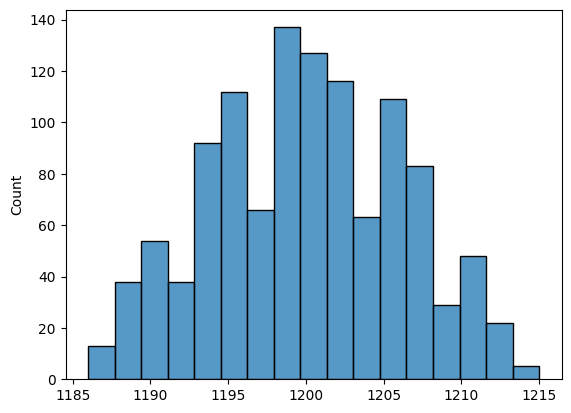

In [18]:
sns.histplot(one_probe['timestamp']- one_probe['time_lagged'])
plt.show()

In [19]:
df_prb_info[df_prb_info.prb_id==12794]

,prb_id,ASN,country_code,is_anchor,system,long,lat
14,12794,12389.0,RU,False,system: V3,30.9915,59.8795


In [20]:
#for col in one_probe.columns[2:]:
print(one_probe[one_probe.avg<15]['from'].value_counts())

from
178.71.92.85     566
178.67.67.104    450
5.142.4.118       62
Name: count, dtype: int64


In [21]:
def replace_out(df, col):
    first_quartile =  np.percentile(one_probe.avg,  25)
    third_quartile = np.percentile(one_probe.avg,  75)
    iqr = third_quartile - first_quartile
    
    for i, row in df.iterrows():
        if row[col]<(first_quartile - 1.5 * iqr)  or row[col]>(third_quartile + 1.5 * iqr):
            df.at[i,col] = df.loc[i-1, col]
        #if row[col]>15:
        #    df.at[i,col] = df.loc[i-1, col]

In [22]:
replace_out(one_probe, col='avg')

## Исследование через numpy

In [23]:
scl = StandardScaler().fit(one_probe['avg'].values.reshape(-1, 1))
one_probe['avg'] = one_probe['avg'].apply(lambda x: scl.transform(np.array(x).reshape(-1,1))[0][0] )

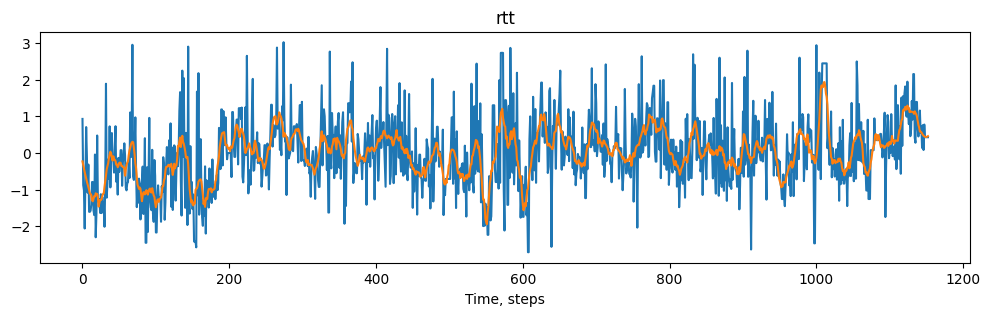

In [24]:
plt.rcParams["figure.figsize"] = (12, 3)
plt.plot(one_probe['avg'])
plt.plot(savgol_filter(one_probe['avg'], 20, 2))
plt.title('rtt')
plt.xlabel("Time, steps")
plt.show()

In [25]:
one_probe['new_avg'] = savgol_filter(one_probe['avg'], 20, 2)

In [26]:
fft_res = np.fft.fft(one_probe['avg'])
duration = len(one_probe)
freq = np.fft.fftfreq(duration, 1200)
len(freq)

1153

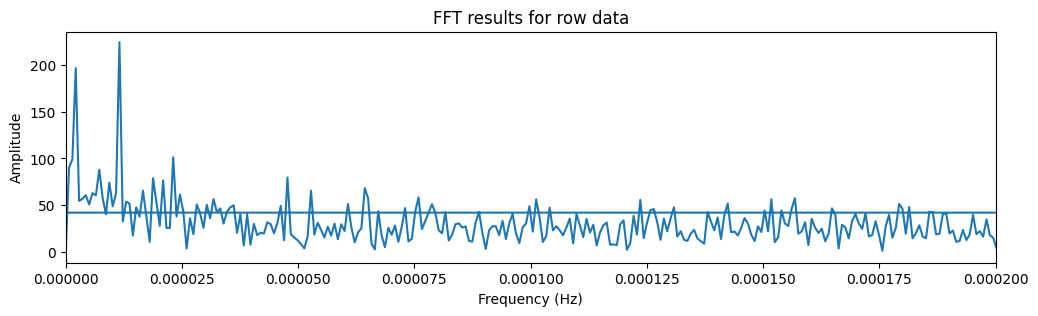

In [27]:
plt.plot(freq, np.abs(fft_res))
plt.title('FFT results for row data')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim([0, 0.0002])
plt.show()

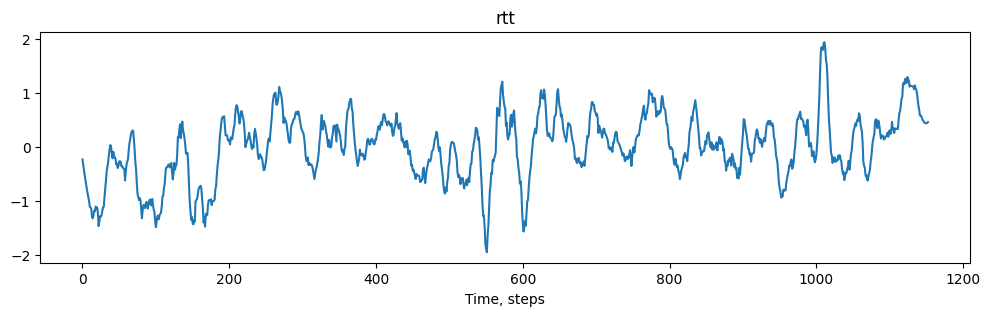

In [28]:
plt.rcParams["figure.figsize"] = (12, 3)
plt.plot(range(len(one_probe)), one_probe['new_avg'])
plt.title('rtt')
plt.xlabel("Time, steps")
plt.show()

In [29]:
fft_res = np.fft.fft(one_probe['new_avg'])
duration = len(one_probe)
freq = np.fft.fftfreq(duration, 1200)
len(freq)

1153

In [30]:
fft_res = fft_res[freq>=0]
freq = freq[freq>=0]

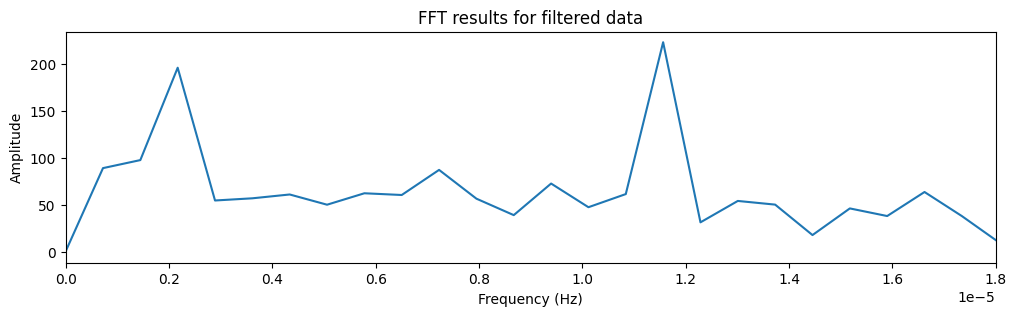

In [31]:
plt.plot(freq, np.abs(fft_res))
plt.title('FFT results for filtered data')
plt.xlabel('Frequency (Hz)')

plt.ylabel('Amplitude')
plt.xlim([0, 0.000018])
plt.show()

In [32]:
m1, m2  = find_two_max(np.abs(fft_res))

In [33]:
m1

223.5915724347475

In [34]:
m2

196.45321994705594

In [35]:
freq[np.abs(fft_res)==m1]

array([1.15640358e-05])

In [36]:
freq[np.abs(fft_res)==m2]

array([2.16825672e-06])

In [37]:
1 / freq[np.abs(fft_res)==m1] / 60/60/24

array([1.00086806])

In [38]:
1 / freq[np.abs(fft_res)==m2 ] / 60/60/24

array([5.33796296])

In [39]:
1 / freq[3] / 60/60/24

5.337962962962963

In [40]:
1 / freq[2] / 60/60/24

8.006944444444445

In [41]:
# всего данных в днях
(len(one_probe)-1)*20 / 60 / 24

16.0

In [42]:
max(one_probe['dtime']) - min(one_probe['dtime'])

Timedelta('15 days 23:59:58')

## Использование scipy

In [43]:
from scipy.fft import fft, ifft
from scipy import signal

In [44]:
f, t, Sxx = signal.spectrogram(one_probe.avg, fs=1/1200)

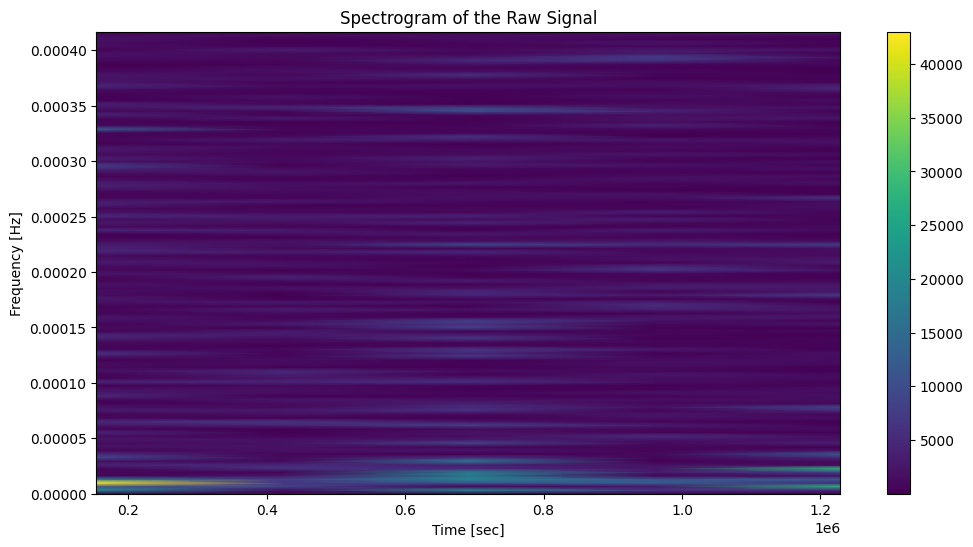

In [45]:
plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.xlabel('Time [sec]')
plt.ylabel('Frequency [Hz]')
plt.title('Spectrogram of the Raw Signal')
plt.colorbar()
plt.show()

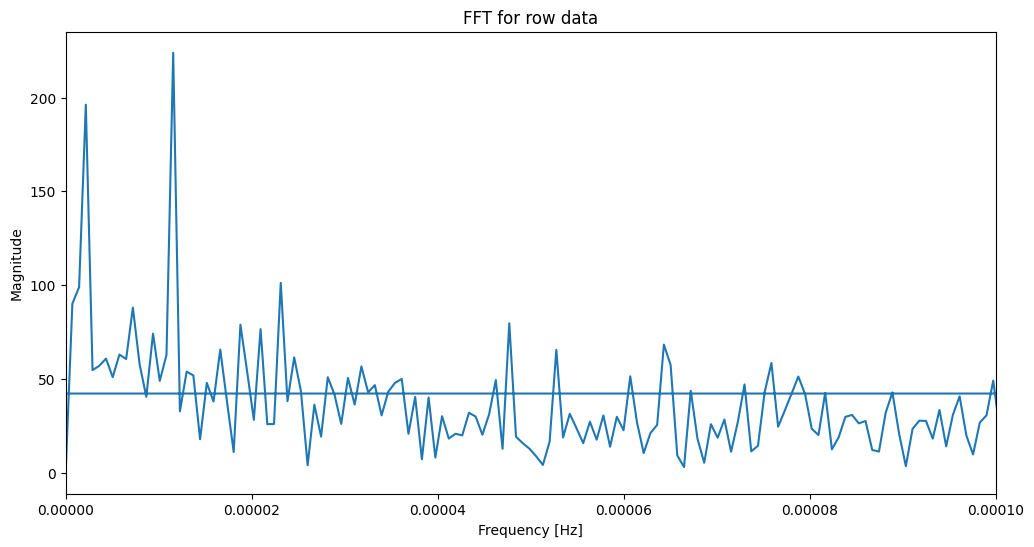

In [46]:
# 1. Compute the FFT of the signal
sig = one_probe.avg.values
fft_data = fft(sig)

# 2. Compute the frequency axis
sample_rate = 1/1200  # Sampling rate in Hz
frequencies = np.fft.fftfreq(len(sig), 1/sample_rate)

# 3. Plot the 2D graph
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(fft_data))
plt.xlim([0, 0.0001])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('FFT for row data')
plt.show()

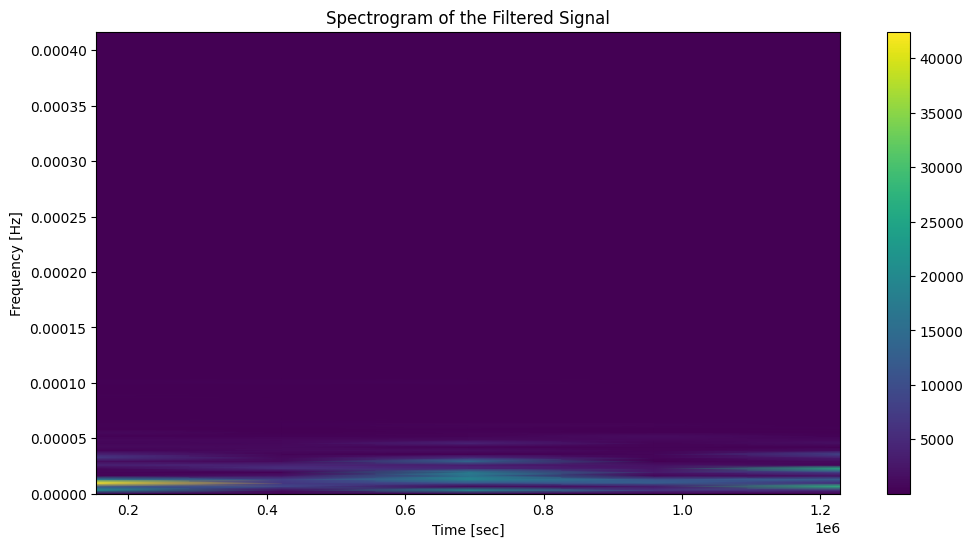

In [47]:
f, t, Sxx = signal.spectrogram(one_probe.new_avg, fs=1/1200)

plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.xlabel('Time [sec]')
plt.ylabel('Frequency [Hz]')
plt.title('Spectrogram of the Filtered Signal')
plt.colorbar()
plt.show()

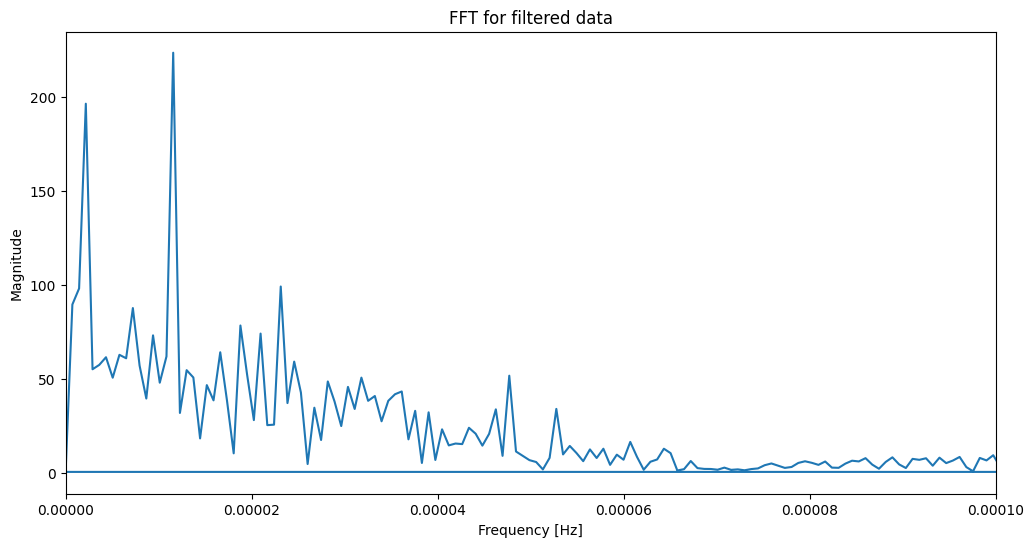

In [48]:
# 1. Compute the FFT of the signal
sig = one_probe.new_avg.values
fft_data = fft(sig)

# 2. Compute the frequency axis
sample_rate = 1/1200  # Sampling rate in Hz
frequencies = np.fft.fftfreq(len(sig), 1/sample_rate)

# 3. Plot the 2D graph
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(fft_data))
plt.xlim([0, 0.0001])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('FFT for filtered data')
plt.show()

# Исследование пробы 23082

In [49]:
one_probe = data[data.prb_id==23082].copy()

In [50]:
one_probe = one_probe.reset_index()

In [51]:
one_probe['time_lagged'] = one_probe['timestamp'].shift(1)

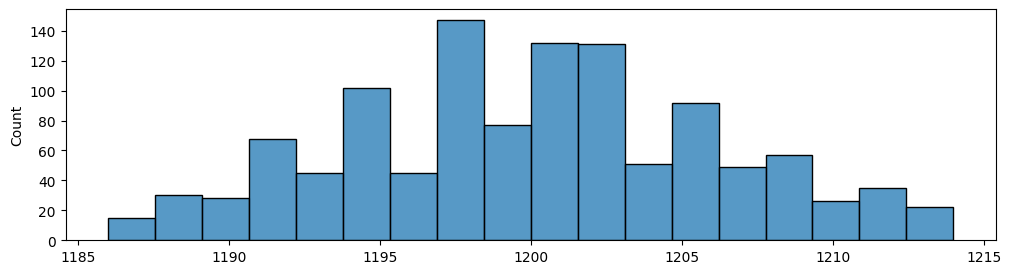

In [52]:
sns.histplot(one_probe['timestamp']- one_probe['time_lagged'])
plt.show()

In [53]:
df_prb_info[df_prb_info.prb_id==23082]

,prb_id,ASN,country_code,is_anchor,system,long,lat
32,23082,200161.0,RU,False,system: V3,37.7215,55.7385


In [54]:
replace_out(one_probe, col='avg')

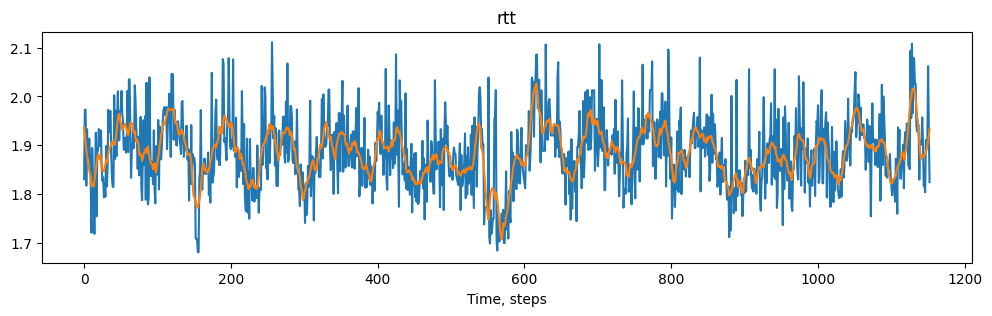

In [55]:
plt.rcParams["figure.figsize"] = (12, 3)
plt.plot(one_probe['avg'])
plt.plot(savgol_filter(one_probe['avg'], 20, 2))
plt.title('rtt')
plt.xlabel("Time, steps")
plt.show()

## Исследование через numpy

In [56]:
scl = StandardScaler().fit(one_probe['avg'].values.reshape(-1, 1))
one_probe['avg'] = one_probe['avg'].apply(lambda x: scl.transform(np.array(x).reshape(-1,1))[0][0] )

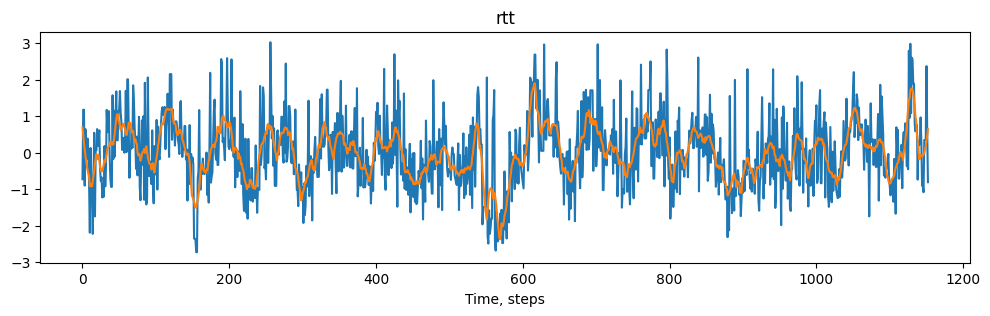

In [57]:
plt.rcParams["figure.figsize"] = (12, 3)
plt.plot(one_probe['avg'])
plt.plot(savgol_filter(one_probe['avg'], 20, 2))
plt.title('rtt')
plt.xlabel("Time, steps")
plt.show()

In [58]:
one_probe['new_avg'] = savgol_filter(one_probe['avg'], 20, 2)

In [59]:
fft_res = np.fft.fft(one_probe['avg'])
duration = len(one_probe)
freq = np.fft.fftfreq(duration, 1200)
len(freq)

1153

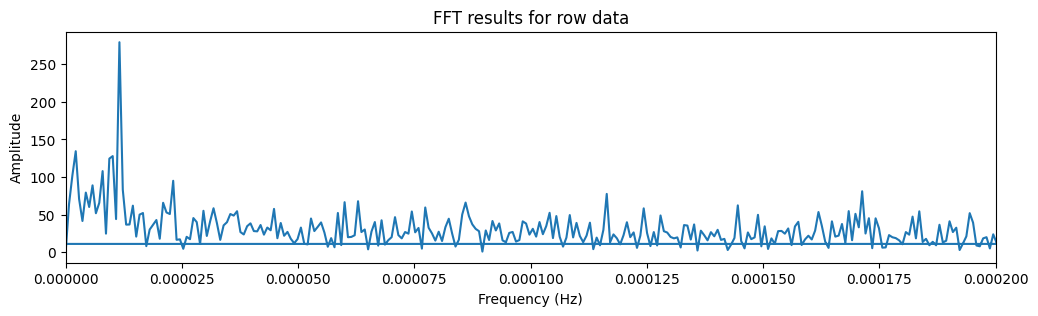

In [60]:
plt.plot(freq, np.abs(fft_res))
plt.title('FFT results for row data')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim([0, 0.0002])
plt.show()

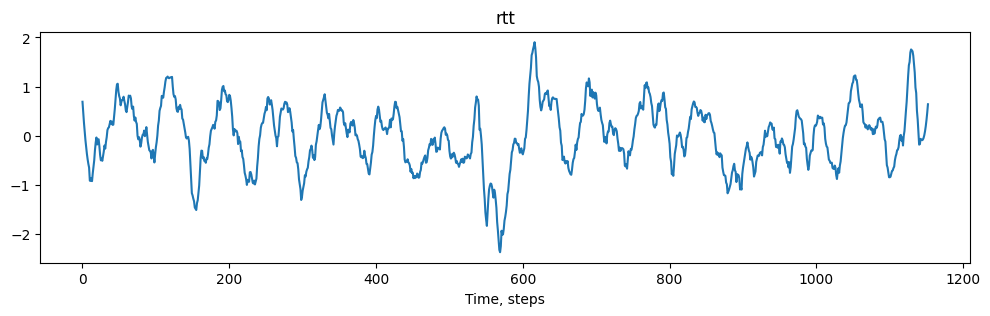

In [61]:
plt.rcParams["figure.figsize"] = (12, 3)
plt.plot(range(len(one_probe)), one_probe['new_avg'])
plt.title('rtt')
plt.xlabel("Time, steps")
plt.show()

In [62]:
fft_res = np.fft.fft(one_probe['new_avg'])
duration = len(one_probe)
freq = np.fft.fftfreq(duration, 1200)
len(freq)

1153

In [63]:
fft_res = fft_res[freq>=0]
freq = freq[freq>=0]

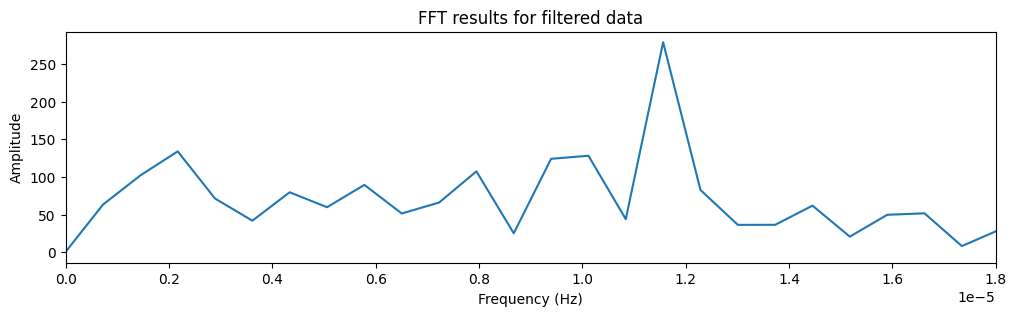

In [64]:
plt.plot(freq, np.abs(fft_res))
plt.title('FFT results for filtered data')
plt.xlabel('Frequency (Hz)')

plt.ylabel('Amplitude')
plt.xlim([0, 0.000018])
plt.show()

In [65]:
m1, m2  = find_two_max(np.abs(fft_res))

In [66]:
freq[np.abs(fft_res)==m1]

array([1.15640358e-05])

In [67]:
freq[np.abs(fft_res)==m2]

array([2.16825672e-06])

In [68]:
1 / freq[np.abs(fft_res)==m1] / 60/60/24

array([1.00086806])

In [69]:
1 / freq[np.abs(fft_res)==m2 ] / 60/60/24

array([5.33796296])

In [70]:
1 / freq[3] / 60/60/24

5.337962962962963

In [71]:
1 / freq[2] / 60/60/24

8.006944444444445

## Использование scipy

In [72]:
from scipy.fft import fft, ifft
from scipy import signal

In [73]:
f, t, Sxx = signal.spectrogram(one_probe.avg, fs=1/1200)

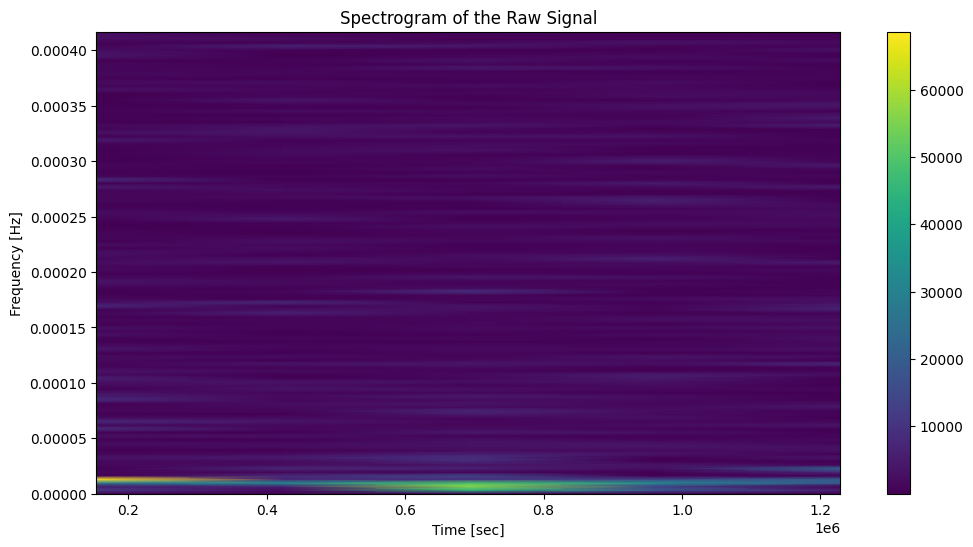

In [74]:
plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.xlabel('Time [sec]')
plt.ylabel('Frequency [Hz]')
plt.title('Spectrogram of the Raw Signal')
plt.colorbar()
plt.show()

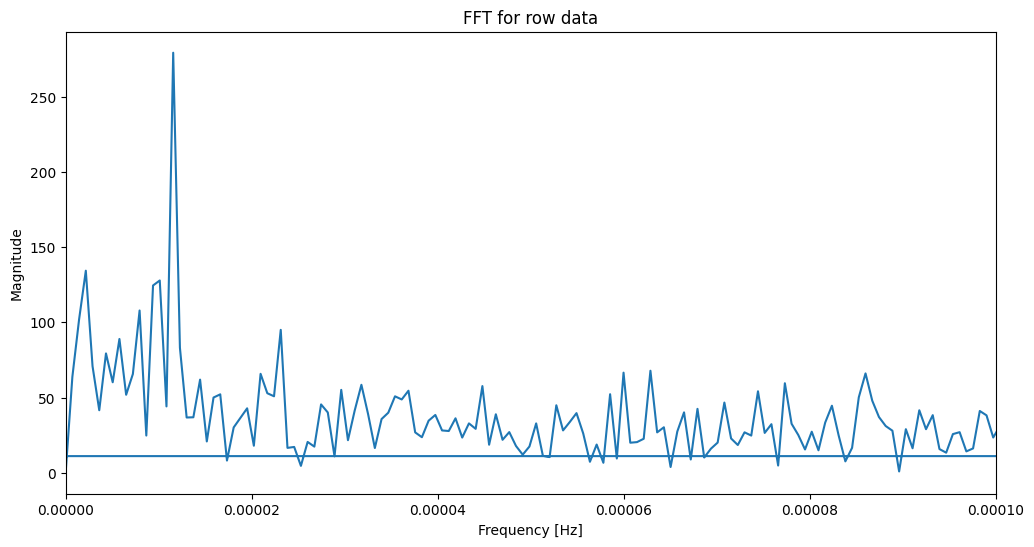

In [75]:
# 1. Compute the FFT of the signal
sig = one_probe.avg.values
fft_data = fft(sig)

# 2. Compute the frequency axis
sample_rate = 1/1200  # Sampling rate in Hz
frequencies = np.fft.fftfreq(len(sig), 1/sample_rate)

# 3. Plot the 2D graph
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(fft_data))
plt.xlim([0, 0.0001])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('FFT for row data')
plt.show()

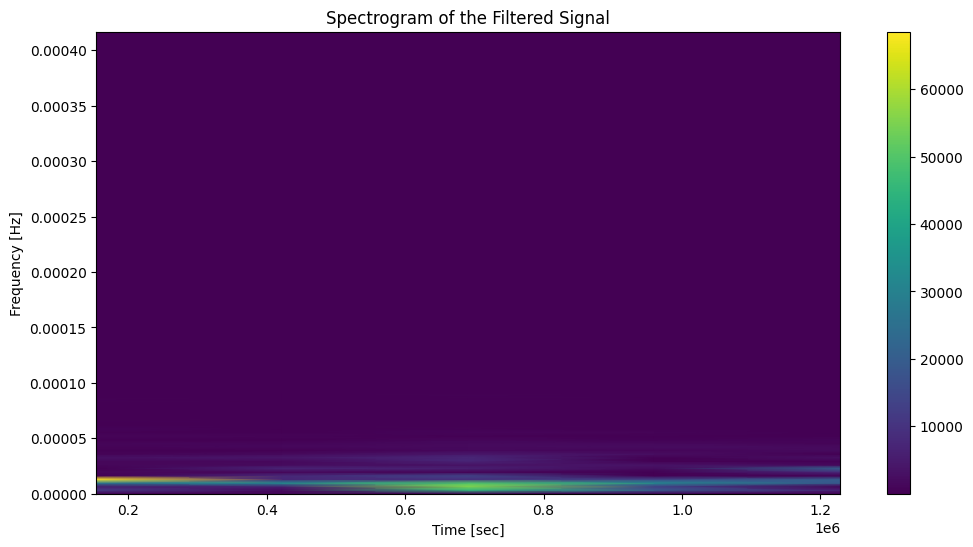

In [76]:
f, t, Sxx = signal.spectrogram(one_probe.new_avg, fs=1/1200)

plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.xlabel('Time [sec]')
plt.ylabel('Frequency [Hz]')
plt.title('Spectrogram of the Filtered Signal')
plt.colorbar()
plt.show()

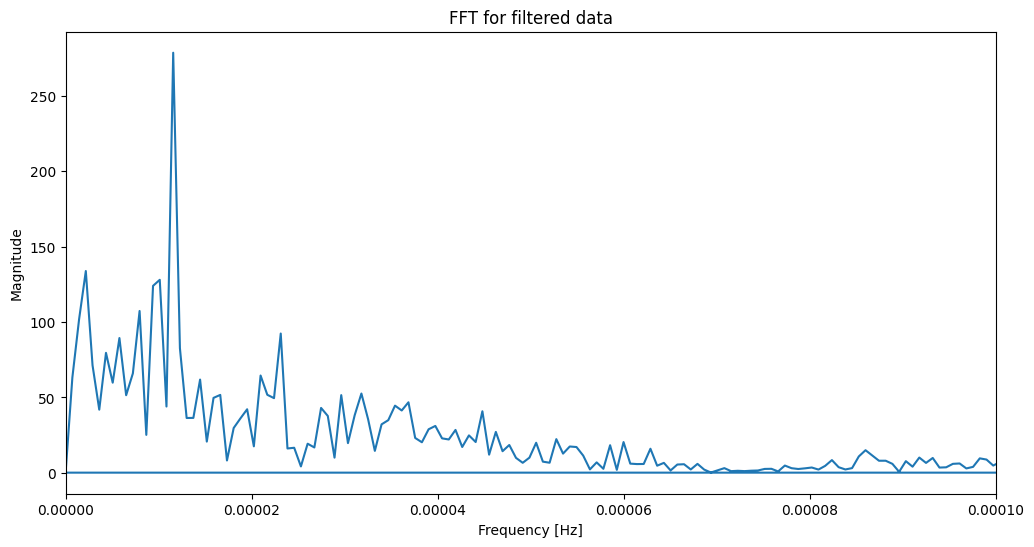

In [77]:
# 1. Compute the FFT of the signal
sig = one_probe.new_avg.values
fft_data = fft(sig)

# 2. Compute the frequency axis
sample_rate = 1/1200  # Sampling rate in Hz
frequencies = np.fft.fftfreq(len(sig), 1/sample_rate)

# 3. Plot the 2D graph
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(fft_data))
plt.xlim([0, 0.0001])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('FFT for filtered data')
plt.show()

# Исследование пробы 35437

In [78]:
one_probe = data[data.prb_id==35437].copy()

In [79]:
one_probe = one_probe.reset_index()

In [80]:
one_probe['time_lagged'] = one_probe['timestamp'].shift(1)

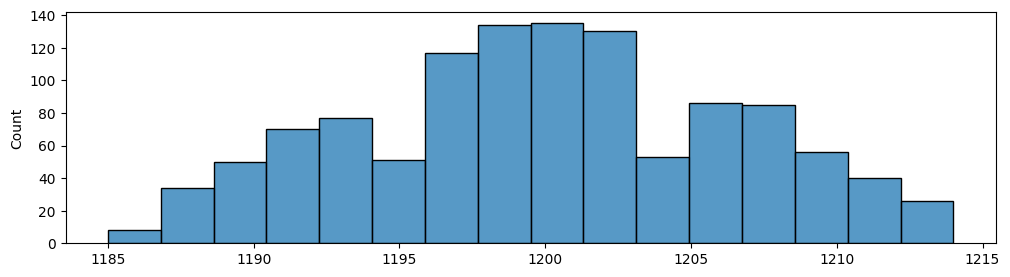

In [81]:
sns.histplot(one_probe['timestamp']- one_probe['time_lagged'])
plt.show()

In [82]:
df_prb_info[df_prb_info.prb_id==23082]

,prb_id,ASN,country_code,is_anchor,system,long,lat
32,23082,200161.0,RU,False,system: V3,37.7215,55.7385


In [83]:
replace_out(one_probe, col='avg')

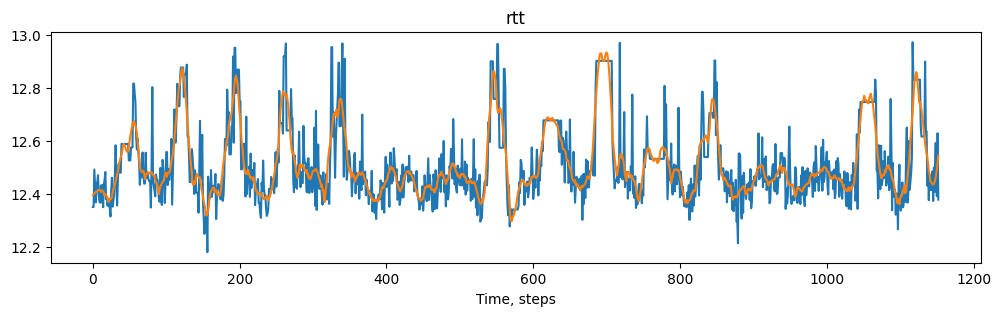

In [84]:
plt.rcParams["figure.figsize"] = (12, 3)
plt.plot(one_probe['avg'])
plt.plot(savgol_filter(one_probe['avg'], 20, 2))
plt.title('rtt')
plt.xlabel("Time, steps")
plt.show()

## Исследование через numpy

In [85]:
scl = StandardScaler().fit(one_probe['avg'].values.reshape(-1, 1))
one_probe['avg'] = one_probe['avg'].apply(lambda x: scl.transform(np.array(x).reshape(-1,1))[0][0] )

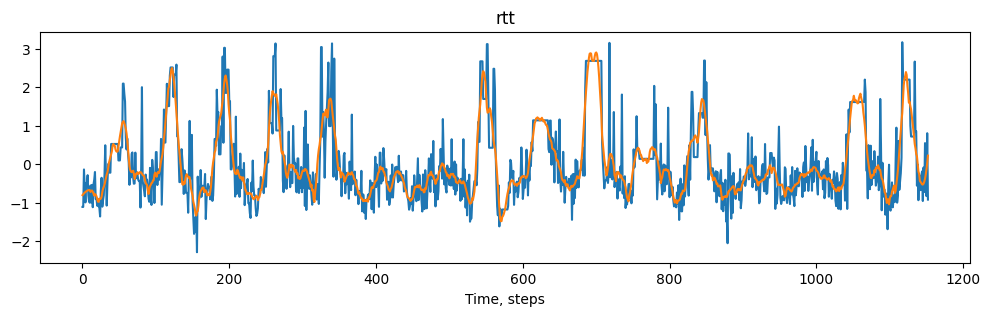

In [86]:
plt.rcParams["figure.figsize"] = (12, 3)
plt.plot(one_probe['avg'])
plt.plot(savgol_filter(one_probe['avg'], 20, 2))
plt.title('rtt')
plt.xlabel("Time, steps")
plt.show()

In [87]:
one_probe['new_avg'] = savgol_filter(one_probe['avg'], 20, 2)

In [88]:
fft_res = np.fft.fft(one_probe['avg'])
duration = len(one_probe)
freq = np.fft.fftfreq(duration, 1200)
len(freq)

1153

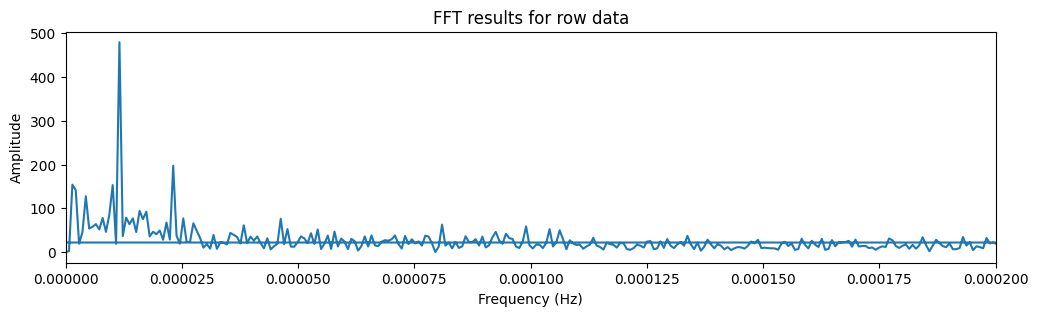

In [89]:
plt.plot(freq, np.abs(fft_res))
plt.title('FFT results for row data')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Amplitude')
plt.xlim([0, 0.0002])
plt.show()

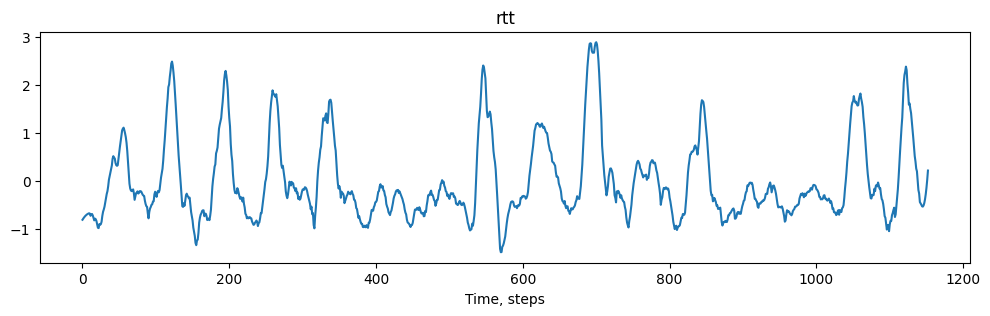

In [90]:
plt.rcParams["figure.figsize"] = (12, 3)
plt.plot(range(len(one_probe)), one_probe['new_avg'])
plt.title('rtt')
plt.xlabel("Time, steps")
plt.show()

In [91]:
fft_res = np.fft.fft(one_probe['new_avg'])
duration = len(one_probe)
freq = np.fft.fftfreq(duration, 1200)
len(freq)

1153

In [92]:
fft_res = fft_res[freq>=0]
freq = freq[freq>=0]

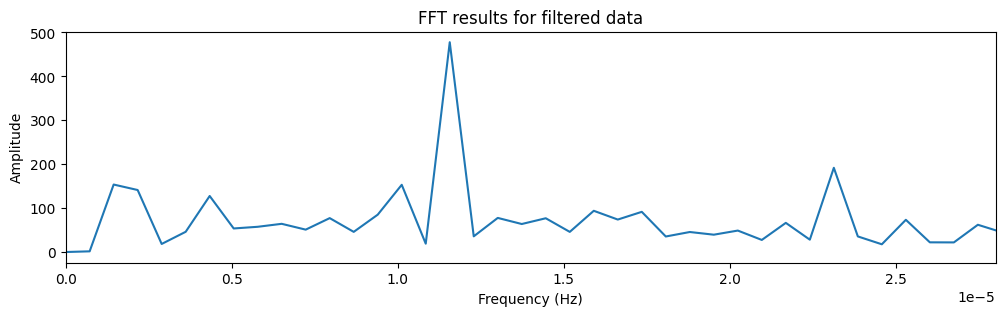

In [93]:
plt.plot(freq, np.abs(fft_res))
plt.title('FFT results for filtered data')
plt.xlabel('Frequency (Hz)')

plt.ylabel('Amplitude')
plt.xlim([0, 0.000028])
plt.show()

In [94]:
m1, m2  = find_two_max(np.abs(fft_res))

In [95]:
freq[np.abs(fft_res)==m1]

array([1.15640358e-05])

In [96]:
freq[np.abs(fft_res)==m2]

array([2.31280717e-05])

In [97]:
1 / freq[np.abs(fft_res)==m1] / 60/60/24

array([1.00086806])

In [98]:
1 / freq[np.abs(fft_res)==m2 ] / 60/60/24

array([0.50043403])

## Использование scipy

In [99]:
from scipy.fft import fft, ifft
from scipy import signal

In [100]:
f, t, Sxx = signal.spectrogram(one_probe.avg, fs=1/1200)

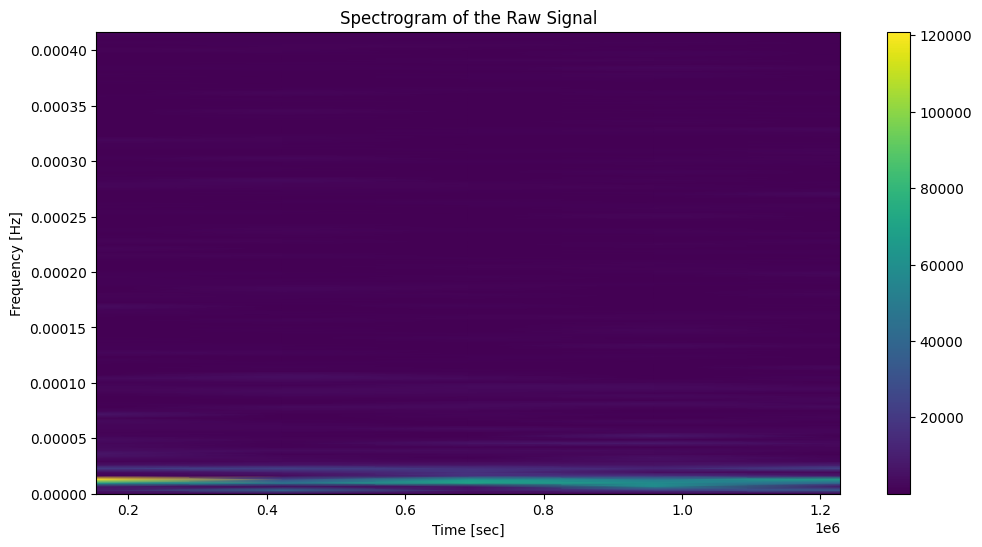

In [101]:
plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.xlabel('Time [sec]')
plt.ylabel('Frequency [Hz]')
plt.title('Spectrogram of the Raw Signal')
plt.colorbar()
plt.show()

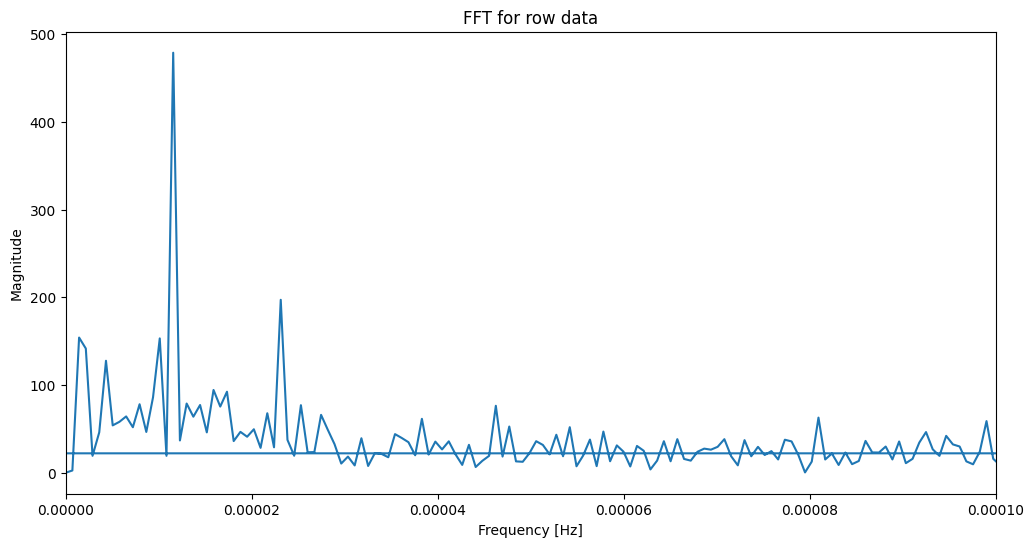

In [102]:
# 1. Compute the FFT of the signal
sig = one_probe.avg.values
fft_data = fft(sig)

# 2. Compute the frequency axis
sample_rate = 1/1200  # Sampling rate in Hz
frequencies = np.fft.fftfreq(len(sig), 1/sample_rate)

# 3. Plot the 2D graph
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(fft_data))
plt.xlim([0, 0.0001])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('FFT for row data')
plt.show()

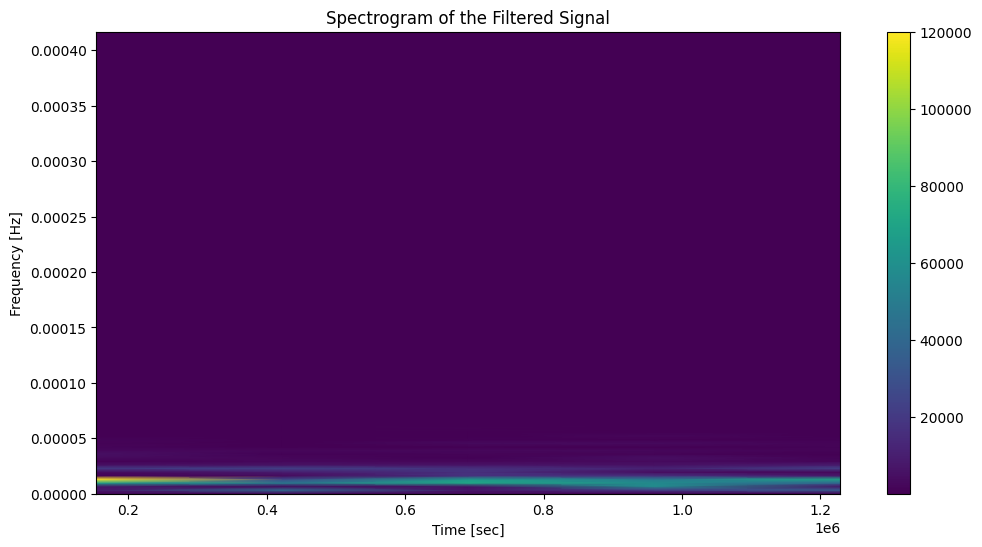

In [103]:
f, t, Sxx = signal.spectrogram(one_probe.new_avg, fs=1/1200)

plt.figure(figsize=(12, 6))
plt.pcolormesh(t, f, Sxx, shading='gouraud')
plt.xlabel('Time [sec]')
plt.ylabel('Frequency [Hz]')
plt.title('Spectrogram of the Filtered Signal')
plt.colorbar()
plt.show()

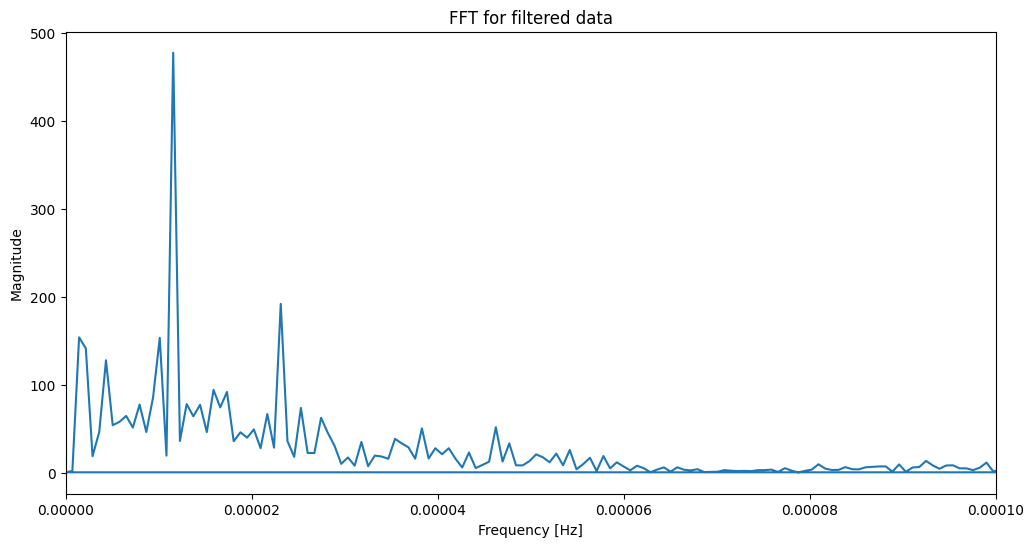

In [104]:
# 1. Compute the FFT of the signal
sig = one_probe.new_avg.values
fft_data = fft(sig)

# 2. Compute the frequency axis
sample_rate = 1/1200  # Sampling rate in Hz
frequencies = np.fft.fftfreq(len(sig), 1/sample_rate)

# 3. Plot the 2D graph
plt.figure(figsize=(12, 6))
plt.plot(frequencies, np.abs(fft_data))
plt.xlim([0, 0.0001])
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude')
plt.title('FFT for filtered data')
plt.show()

# Усреденные характеристики

In [118]:
group['avg'].values

array([21.27045925, 21.01063675, 21.08655675, ..., 13.95055925,
       13.937151  , 13.960865  ])

In [108]:
df = data_v3.copy()

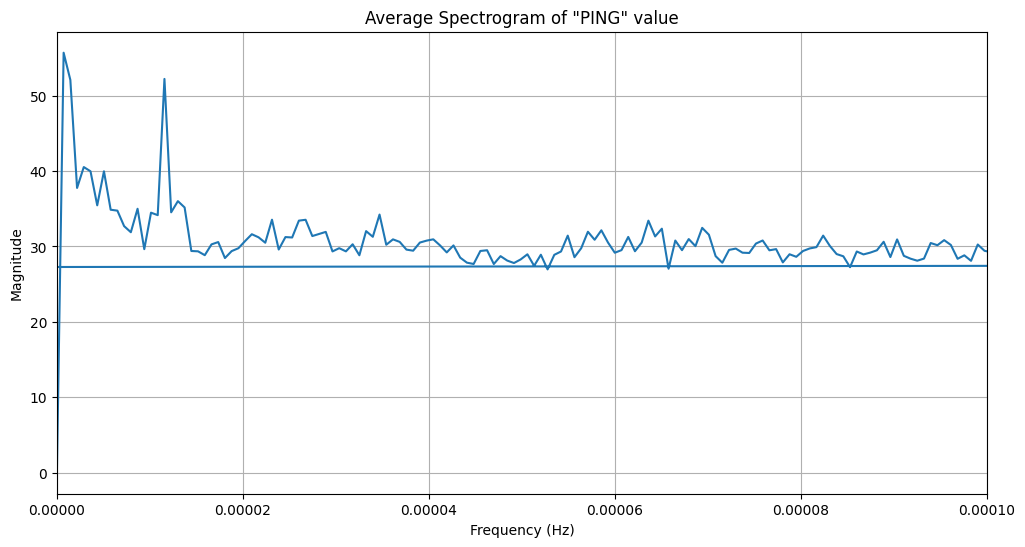

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sample DataFrame creation (replace this with your actual DataFrame)
# df = pd.DataFrame({
#     'prb_id': [...],
#     'step_num': [...],
#     'avg': [...]
# })

# Function to compute FFT and return magnitude
def compute_fft(signal):
    fft_result = np.fft.fft(signal)
    magnitude = np.abs(fft_result)
    return magnitude

# Group by 'prb_id' and compute the FFT for each group
fft_results = []

for prb_id, group in df.groupby('prb_id'):
    # Extract the 'avg' values
    scl = StandardScaler()
    signal = scl.fit_transform(group['avg'].values.reshape(-1, 1))
    signal = signal.reshape(1, -1)[0]
    # Compute the FFT
    magnitude = compute_fft(signal)
    fft_results.append(magnitude)

# Find the maximum length of FFT results for padding
max_length = max(len(result) for result in fft_results)

# Pad FFT results to the same length
padded_fft = np.array([np.pad(result, (0, max_length - len(result)), 'constant') for result in fft_results])

# Average the padded FFT results
average_fft = np.mean(padded_fft, axis=0)

# Prepare for plotting
#frequencies = np.fft.fftfreq(max_length)
sample_rate = 1/1200  # Sampling rate in Hz
frequencies = np.fft.fftfreq(max_length, 1/sample_rate)


# Plotting the average spectrogram
plt.figure(figsize=(12, 6))
plt.plot(frequencies, average_fft)
plt.title('Average Spectrogram of "PING" value')
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
#plt.xlim(0, np.max(frequencies))  # Limit x-axis to positive frequencies
plt.xlim([0, 0.0001])
plt.grid()
plt.show()

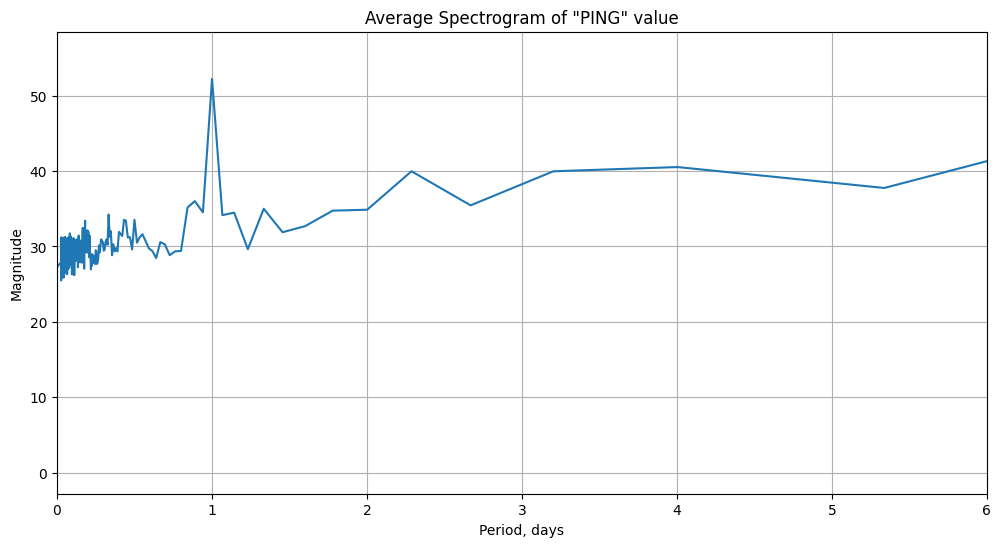

In [151]:
periods = [16 if f==0 else 1/f/60/60/24 for f in frequencies]

plt.figure(figsize=(12, 6))
plt.plot(periods, average_fft)
plt.title('Average Spectrogram of "PING" value')
plt.xlabel('Period, days')
plt.ylabel('Magnitude')
plt.xlim([0, 6])
plt.grid()
plt.show()

In [138]:
1 / frequencies[1] / 60 / 60 / 24

16.01388888888889

In [145]:
# всего длительность измерений
(one_probe.timestamp.max() - one_probe.timestamp.min()) / 60 / 60 / 24

16.000127314814815